In [ ]:
DATA PROCESSING, CLEANING, AND MANIPULATION

DATA PROCESSING

In [10]:
import pandas as pd
import numpy as np
import os

# Base path 
base_path = r"G:\My Drive\Data Analysis Projects\Superstore\dataset"

# List of order files
order_files = ['orders_2016.csv', 'orders_2017.csv', 'orders_2018.csv', 'orders_2019.csv', 'orders_2020.csv']

# Loading and concatenating order files
df_list = []

for file in order_files:
    full_path = os.path.join(base_path, file)
    
    # We use encoding='latin1' to bypass the UnicodeDecodeError 
    temp_df = pd.read_csv(full_path, encoding='latin1')
    df_list.append(temp_df)
    print(f"Successfully loaded {file} from {full_path}")

orders = pd.concat(df_list, ignore_index=True)

# Loading supplementary files from the same local path
returns = pd.read_csv(os.path.join(base_path, 'returns.csv'), encoding='latin1')
sales_rep = pd.read_csv(os.path.join(base_path, 'sales_rep.csv'), encoding='latin1')

print(f"\nSuccess! Total rows merged: {orders.shape[0]}")
print(orders.head())

Successfully loaded orders_2016.csv from G:\My Drive\Data Analysis Projects\Superstore\dataset\orders_2016.csv
Successfully loaded orders_2017.csv from G:\My Drive\Data Analysis Projects\Superstore\dataset\orders_2017.csv
Successfully loaded orders_2018.csv from G:\My Drive\Data Analysis Projects\Superstore\dataset\orders_2018.csv
Successfully loaded orders_2019.csv from G:\My Drive\Data Analysis Projects\Superstore\dataset\orders_2019.csv
Successfully loaded orders_2020.csv from G:\My Drive\Data Analysis Projects\Superstore\dataset\orders_2020.csv

Success! Total rows merged: 11979
   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       6  CA-2016-115812   6/9/2016  6/14/2016  Standard Class    BH-11710   
1       7  CA-2016-115812   6/9/2016  6/14/2016  Standard Class    BH-11710   
2       8  CA-2016-115812   6/9/2016  6/14/2016  Standard Class    BH-11710   
3       9  CA-2016-115812   6/9/2016  6/14/2016  Standard Class    BH-11710   
4      10  CA-2

DATA CLEANING

In [11]:
orders.isna().sum()

Row ID             0
Order ID           0
Order Date         0
Ship Date          0
Ship Mode          0
Customer ID        0
Customer Name      0
Segment            0
Country/Region     0
City               0
State              0
Postal Code       11
Region             0
Product ID         0
Category           0
Sub-Category       0
Product Name       0
Sales              0
Quantity           0
Discount           0
Profit             0
Returned           1
dtype: int64

In [12]:
orders['Postal Code'] = orders['Postal Code'].fillna(0).astype(int).astype(str).str.zfill(5)

In [13]:
# Identifying and verifying the null 
null_row = orders[orders['Returned'].isnull()]
print("Found null in Order ID:", null_row['Order ID'].values)

# Using the returns.csv file to create a reliable 'Returned' status
# We create a list of all Order IDs that were actually returned
returned_ids_list = returns['Order ID'].unique()

# Creating a new, clean column. 
# If the ID is in the returns list, it's 'Yes', otherwise it's 'No'
orders['Returned_Final'] = orders['Order ID'].apply(lambda x: 'Yes' if x in returned_ids_list else 'No')

# Dropping the old 'Returned' column that had the null value
orders.drop(columns=['Returned'], inplace=True)
orders.rename(columns={'Returned_Final': 'Returned'}, inplace=True)

print("Null value handled. 'Returned' column is now 100% accurate based on returns.csv.")

Found null in Order ID: ['CA-2017-148614']
Null value handled. 'Returned' column is now 100% accurate based on returns.csv.


In [15]:
orders.isna().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State             0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
Returned          0
dtype: int64

In [16]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11979 entries, 0 to 11978
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          11979 non-null  int64  
 1   Order ID        11979 non-null  object 
 2   Order Date      11979 non-null  object 
 3   Ship Date       11979 non-null  object 
 4   Ship Mode       11979 non-null  object 
 5   Customer ID     11979 non-null  object 
 6   Customer Name   11979 non-null  object 
 7   Segment         11979 non-null  object 
 8   Country/Region  11979 non-null  object 
 9   City            11979 non-null  object 
 10  State           11979 non-null  object 
 11  Postal Code     11979 non-null  object 
 12  Region          11979 non-null  object 
 13  Product ID      11979 non-null  object 
 14  Category        11979 non-null  object 
 15  Sub-Category    11979 non-null  object 
 16  Product Name    11979 non-null  object 
 17  Sales           11979 non-null 

In [17]:
orders['Order Date'] = pd.to_datetime(orders['Order Date'])
orders['Ship Date'] = pd.to_datetime(orders['Ship Date'])

In [18]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11979 entries, 0 to 11978
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          11979 non-null  int64         
 1   Order ID        11979 non-null  object        
 2   Order Date      11979 non-null  datetime64[ns]
 3   Ship Date       11979 non-null  datetime64[ns]
 4   Ship Mode       11979 non-null  object        
 5   Customer ID     11979 non-null  object        
 6   Customer Name   11979 non-null  object        
 7   Segment         11979 non-null  object        
 8   Country/Region  11979 non-null  object        
 9   City            11979 non-null  object        
 10  State           11979 non-null  object        
 11  Postal Code     11979 non-null  object        
 12  Region          11979 non-null  object        
 13  Product ID      11979 non-null  object        
 14  Category        11979 non-null  object        
 15  Su

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Defining the numerical columns to check
num_cols = ['Sales', 'Quantity', 'Discount', 'Profit']

# Iterating through columns to calculate IQR and identify outliers
outlier_summary = []

for col in num_cols:
    Q1 = orders[col].quantile(0.25)
    Q3 = orders[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Calculating Upper and Lower Bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filtering the outliers
    outliers = orders[(orders[col] < lower_bound) | (orders[col] > upper_bound)]
    
    outlier_summary.append({
        'Column': col,
        'Outlier Count': len(outliers),
        'Min Value': orders[col].min(),
        'Max Value': orders[col].max(),
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound
    })

# Displaying the summary table
outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df)

     Column  Outlier Count  Min Value  Max Value  Lower Bound  Upper Bound
0     Sales           1411      0.444  22638.480   -273.64500    501.64300
1  Quantity            214      1.000     14.000     -2.50000      9.50000
2  Discount           1022      0.000      0.800     -0.30000      0.50000
3    Profit           2271  -6599.978   8399.976    -39.43415     70.29345


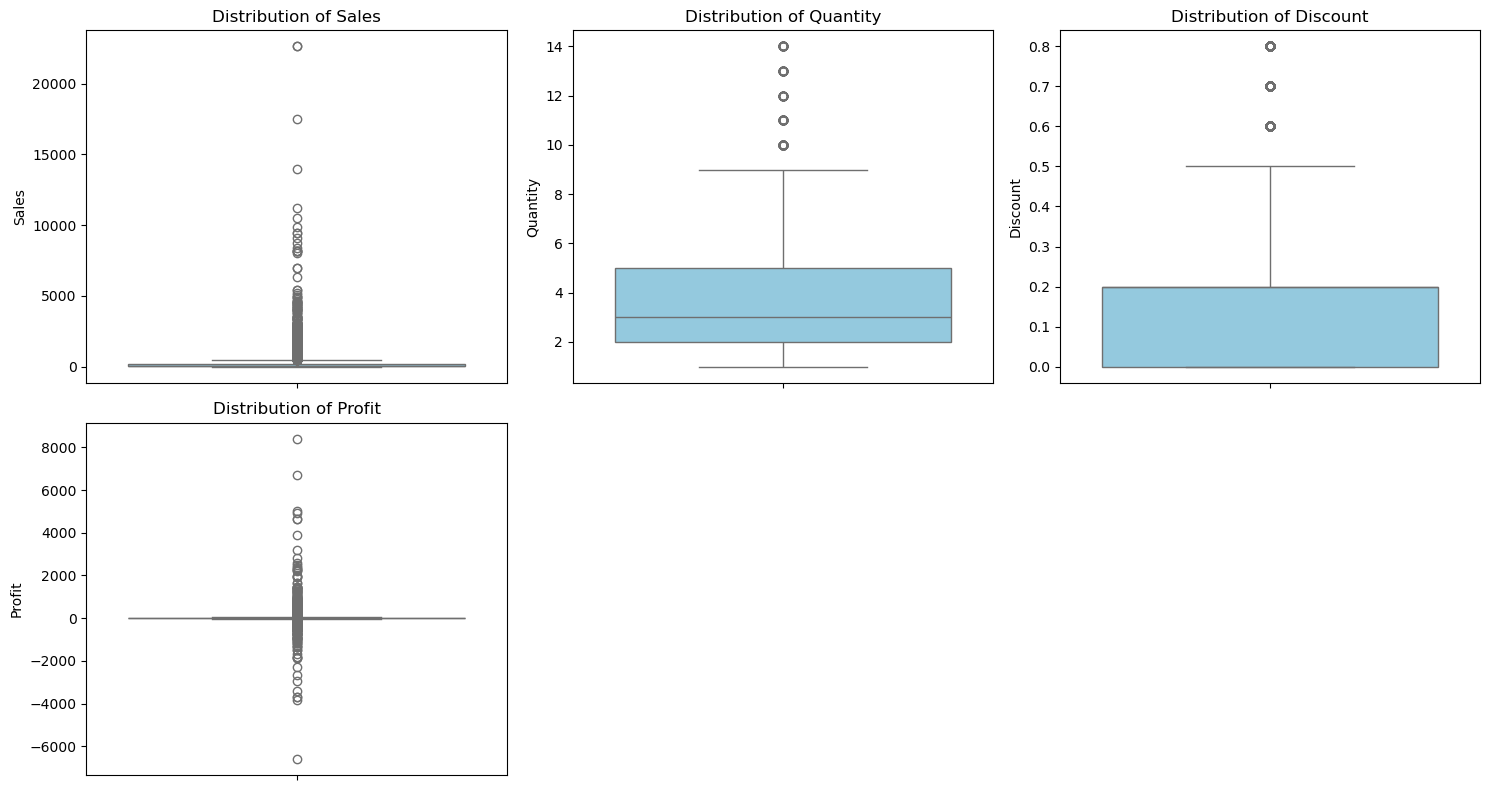

In [34]:
plt.figure(figsize=(15, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=orders[col], color='skyblue')
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.savefig('outlier_analysis_plots.png')

In [35]:
duplicate_rows = orders.duplicated()
print(f"Number of duplicate rows: {duplicate_rows.sum()}")

duplicates = orders[orders.duplicated()]
print(duplicates)

Number of duplicate rows: 0
Empty DataFrame
Columns: [Row ID, Order ID, Order Date, Ship Date, Ship Mode, Customer ID, Customer Name, Segment, Country/Region, City, State, Postal Code, Region, Product ID, Category, Sub-Category, Product Name, Sales, Quantity, Discount, Profit, Returned]
Index: []

[0 rows x 22 columns]


In [41]:
obj_cols = orders.select_dtypes(include=['object']).columns
for col in obj_cols:
    orders[col] = orders[col].str.strip()

In [53]:
orders.drop(['Returned', 'Row ID'], axis=1, inplace=True, errors='ignore')

In [57]:
orders.columns = (orders.columns
              .str.strip()
              .str.replace(' ', '_')
              .str.replace('-', '_')
              .str.replace('/', '_')
              .str.lower())


print("New Standardized Columns:")
print(orders.columns.tolist())

New Standardized Columns:
['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country_region', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit', 'days_to_ship']


In [58]:
orders = orders.reset_index(drop=True)

print(orders.head())
print("Cleaning Process Complete!")
print(f"Total Rows: {len(orders)}")
print(f"Null Values Remaining: {orders.isnull().sum().sum()}")

         order_id order_date  ship_date       ship_mode customer_id  \
0  CA-2016-115812 2016-06-09 2016-06-14  Standard Class    BH-11710   
1  CA-2016-115812 2016-06-09 2016-06-14  Standard Class    BH-11710   
2  CA-2016-115812 2016-06-09 2016-06-14  Standard Class    BH-11710   
3  CA-2016-115812 2016-06-09 2016-06-14  Standard Class    BH-11710   
4  CA-2016-115812 2016-06-09 2016-06-14  Standard Class    BH-11710   

     customer_name   segment country_region         city       state  ...  \
0  Brosina Hoffman  Consumer  United States  Los Angeles  California  ...   
1  Brosina Hoffman  Consumer  United States  Los Angeles  California  ...   
2  Brosina Hoffman  Consumer  United States  Los Angeles  California  ...   
3  Brosina Hoffman  Consumer  United States  Los Angeles  California  ...   
4  Brosina Hoffman  Consumer  United States  Los Angeles  California  ...   

  region       product_id         category sub_category  \
0   West  FUR-FU-10001487        Furniture  Furnish

In [ ]:
DATA MANIPULATION

In [ ]:
Feature Engineering:

In [60]:
orders['days_to_ship'] = (orders['ship_date'] - orders['order_date']).dt.days

In [ ]:
CLEANED CSV FILE

In [61]:
orders.to_csv(r"G:\My Drive\Data Analysis Projects\Superstore\cleaned\orders.csv", index=False)

In [62]:
import os
file_path = r"G:\My Drive\Data Analysis Projects\Superstore\cleaned\orders.csv"
if os.path.exists(file_path):
    print("File successfully created!")

File successfully created!


In [ ]:
DATA CLEANING RETURNS DATASET

In [63]:
returns.columns = (returns.columns
              .str.strip()
              .str.replace(' ', '_')
              .str.replace('-', '_')
              .str.replace('/', '_')
              .str.lower())


print("New Standardized Columns:")
print(returns.columns.tolist())

New Standardized Columns:
['order_id', 'returned']


In [65]:
returns.isna().sum()

order_id    0
returned    0
dtype: int64

In [64]:
returns = returns.reset_index(drop=True)

print(returns.head())
print("Cleaning Process Complete!")
print(f"Total Rows: {len(returns)}")
print(f"Null Values Remaining: {returns.isnull().sum().sum()}")

         order_id returned
0  CA-2016-100762      Yes
1  CA-2016-100867      Yes
2  CA-2016-102652      Yes
3  CA-2016-103373      Yes
4  CA-2016-103744      Yes
Cleaning Process Complete!
Total Rows: 592
Null Values Remaining: 0


In [66]:
returns.to_csv(r"G:\My Drive\Data Analysis Projects\Superstore\cleaned\returns.csv", index=False)

In [67]:
import os
file_path = r"G:\My Drive\Data Analysis Projects\Superstore\cleaned\returns.csv"
if os.path.exists(file_path):
    print("Returns File successfully created!")

Returns File successfully created!


In [ ]:
DATA CLEANING SALES REP DATASET

In [68]:
sales_rep.columns = (sales_rep.columns
              .str.strip()
              .str.replace(' ', '_')
              .str.replace('-', '_')
              .str.replace('/', '_')
              .str.lower())


print("New Standardized Columns:")
print(sales_rep.columns.tolist())

New Standardized Columns:
['region', 'person']


In [69]:
sales_rep = sales_rep.reset_index(drop=True)

print(sales_rep.head())
print("Cleaning Process Complete!")
print(f"Total Rows: {len(sales_rep)}")
print(f"Null Values Remaining: {sales_rep.isnull().sum().sum()}")

    region             person
0     West      Anna Andreadi
1     East        Chuck Magee
2  Central     Kelly Williams
3    South  Cassandra Brandow
Cleaning Process Complete!
Total Rows: 4
Null Values Remaining: 0


In [70]:
sales_rep.to_csv(r"G:\My Drive\Data Analysis Projects\Superstore\cleaned\sales_rep.csv", index=False)

In [71]:
import os
file_path = r"G:\My Drive\Data Analysis Projects\Superstore\cleaned\sales_rep.csv"
if os.path.exists(file_path):
    print("Sales Rep File successfully created!")

Sales Rep File successfully created!
